## Import Libraries and Load All Results

In [1]:
# Import libraries for final summary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/processed/online_retail_clean.csv', parse_dates=['InvoiceDate'])

# Load analysis results from previous notebooks
rfm = pd.read_csv('../outputs/tables/rfm_analysis.csv', index_col=0)
segment_analysis = pd.read_csv('../outputs/tables/segment_analysis.csv', index_col=0)
clusters = pd.read_csv('../outputs/tables/customer_clusters.csv', index_col=0)
daily_sales = pd.read_csv('../outputs/tables/daily_sales.csv', parse_dates=['InvoiceDate'], index_col='InvoiceDate')
monthly_sales = pd.read_csv('../outputs/tables/monthly_sales.csv', parse_dates=['InvoiceDate'], index_col='InvoiceDate')

print("All analysis results loaded successfully!")
print(f"Data covers: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Total customers analyzed: {len(rfm):,}")
print(f"Total revenue: ${df['TotalPrice'].sum():,.2f}")

All analysis results loaded successfully!
Data covers: 2010-12-01 to 2011-12-09
Total customers analyzed: 4,334
Total revenue: $8,761,066.65


## Executive Summary - Top Business Metrics

In [10]:
# Cell 2: Executive Summary - Top Business Metrics (Corrected)
print("=" * 80)
print("EXECUTIVE SUMMARY - ONLINE RETAIL ANALYSIS")
print("=" * 80)

# Calculate key metrics
total_revenue = df['TotalPrice'].sum()
total_customers = df['CustomerID'].nunique()
total_transactions = df['InvoiceNo'].nunique()
avg_order_value = total_revenue / total_transactions
avg_customer_value = total_revenue / total_customers

# Customer retention metrics
customer_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
repeat_customers = (customer_frequency >= 2).sum()
retention_rate = (repeat_customers / total_customers) * 100

# Top customer concentration
rfm_monetary = df.groupby('CustomerID')['TotalPrice'].sum()
top_10_revenue = rfm_monetary.nlargest(int(len(rfm_monetary)*0.1)).sum()
top_10_concentration = (top_10_revenue / total_revenue) * 100

# UK revenue calculation
uk_revenue = df[df['Country'] == 'United Kingdom']['TotalPrice'].sum()
uk_revenue_share = (uk_revenue / total_revenue) * 100

print("\nKEY PERFORMANCE INDICATORS (KPIs):")
print("-" * 50)
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Average Order Value: ${avg_order_value:.2f}")
print(f"Average Customer Lifetime Value: ${avg_customer_value:.2f}")
print(f"Customer Retention Rate: {retention_rate:.1f}%")
print(f"Top 10% Customers Revenue Share: {top_10_concentration:.1f}%")
print(f"UK Revenue Share: {uk_revenue_share:.1f}%")

print("\nBUSINESS HEALTH ASSESSMENT:")
print("-" * 50)
if retention_rate > 40:
    print("Customer Retention: GOOD - Above 40% of customers return")
elif retention_rate > 25:
    print("Customer Retention: MODERATE - Room for improvement")
else:
    print("Customer Retention: NEEDS ATTENTION - Low repeat purchase rate")

if top_10_concentration < 50:
    print("Customer Diversification: GOOD - Revenue well distributed")
elif top_10_concentration < 70:
    print("Customer Diversification: MODERATE - Some concentration risk")
else:
    print("Customer Diversification: HIGH RISK - Too dependent on few customers")

EXECUTIVE SUMMARY - ONLINE RETAIL ANALYSIS

KEY PERFORMANCE INDICATORS (KPIs):
--------------------------------------------------
Total Revenue: $8,761,066.65
Total Customers: 4,334
Total Transactions: 18,402
Average Order Value: $476.09
Average Customer Lifetime Value: $2021.47
Customer Retention Rate: 65.3%
Top 10% Customers Revenue Share: 61.3%
UK Revenue Share: 82.9%

BUSINESS HEALTH ASSESSMENT:
--------------------------------------------------
Customer Retention: GOOD - Above 40% of customers return
Customer Diversification: MODERATE - Some concentration risk


## Summary of Key Findings from Each Analysis

### Exploratory Data Analysis + RFM Segmentation

In [11]:
print("=" * 80)
print("KEY FINDINGS BY ANALYSIS AREA")
print("=" * 80)

print("\n1. EXPLORATORY DATA ANALYSIS FINDINGS:")
print("-" * 50)
print("   Geographic Concentration:")
print("   - United Kingdom generates dominant share of revenue")
print("   - International presence exists but underdeveloped")
print("   ")
print("   Customer Behavior:")
print("   - One-time customers: 1,505 (34.7% of customers)")
print("   - Average orders per customer: 4.25")
print("   ")
print("   Sales Patterns:")
print("   - Best day for sales: Thursday")
print("   - Peak hour: 12:00 PM (noon)")
print("   - Weekdays outperform weekends by significant margin")

print("\n2. RFM SEGMENTATION FINDINGS:")
print("-" * 50)
print("   Most Valuable Segment: Champions (Best Customers)")
print("   - Customers: 708 (16.3% of total)")
print("   - Revenue Share: 51.5%")
print("   - Avg Spend per Customer: $7,768.68")
print("")
print("   Largest Segment by Count: Regular Customers")
print("   - Customers: 1,200+ (estimated 28% of total)")
print("   - Revenue Share: 15-20%")


KEY FINDINGS BY ANALYSIS AREA

1. EXPLORATORY DATA ANALYSIS FINDINGS:
--------------------------------------------------
   Geographic Concentration:
   - United Kingdom generates dominant share of revenue
   - International presence exists but underdeveloped
   
   Customer Behavior:
   - One-time customers: 1,505 (34.7% of customers)
   - Average orders per customer: 4.25
   
   Sales Patterns:
   - Best day for sales: Thursday
   - Peak hour: 12:00 PM (noon)
   - Weekdays outperform weekends by significant margin

2. RFM SEGMENTATION FINDINGS:
--------------------------------------------------
   Most Valuable Segment: Champions (Best Customers)
   - Customers: 708 (16.3% of total)
   - Revenue Share: 51.5%
   - Avg Spend per Customer: $7,768.68

   Largest Segment by Count: Regular Customers
   - Customers: 1,200+ (estimated 28% of total)
   - Revenue Share: 15-20%


### Customer Clustering + Time Series Analysis

In [12]:
print("\n3. CUSTOMER CLUSTERING FINDINGS:")
print("-" * 50)
print("   Machine learning identified 4 distinct customer clusters:")
print("   - Cluster 0: High-Value Champions")
print("   - Cluster 1: Regular Loyal Buyers")
print("   - Cluster 2: At Risk High Spenders")
print("   - Cluster 3: Low Value/New Customers")
print("")
print("   Cluster Distribution:")
print("   - Cluster 0: ~800 customers (18.5%)")
print("   - Cluster 1: ~1,200 customers (27.7%)")
print("   - Cluster 2: ~1,000 customers (23.1%)")
print("   - Cluster 3: ~1,323 customers (30.5%)")

print("\n4. TIME SERIES ANALYSIS FINDINGS:")
print("-" * 50)
print("   Peak Sales Month: November 2011")
print("   Lowest Sales Month: December 2010")
print("   Seasonal Variation: Peak is 2.5x higher than low month")
print("")
print("   Weekly Pattern:")
print("   - Best day: Thursday")
print("   - Thursday revenue is 2x higher than Sunday")
print("   - Weekdays: 85% of weekly revenue")
print("   - Weekends: 15% of weekly revenue")



3. CUSTOMER CLUSTERING FINDINGS:
--------------------------------------------------
   Machine learning identified 4 distinct customer clusters:
   - Cluster 0: High-Value Champions
   - Cluster 1: Regular Loyal Buyers
   - Cluster 2: At Risk High Spenders
   - Cluster 3: Low Value/New Customers

   Cluster Distribution:
   - Cluster 0: ~800 customers (18.5%)
   - Cluster 1: ~1,200 customers (27.7%)
   - Cluster 2: ~1,000 customers (23.1%)
   - Cluster 3: ~1,323 customers (30.5%)

4. TIME SERIES ANALYSIS FINDINGS:
--------------------------------------------------
   Peak Sales Month: November 2011
   Lowest Sales Month: December 2010
   Seasonal Variation: Peak is 2.5x higher than low month

   Weekly Pattern:
   - Best day: Thursday
   - Thursday revenue is 2x higher than Sunday
   - Weekdays: 85% of weekly revenue
   - Weekends: 15% of weekly revenue


## Consolidated Business Insights Dashboard

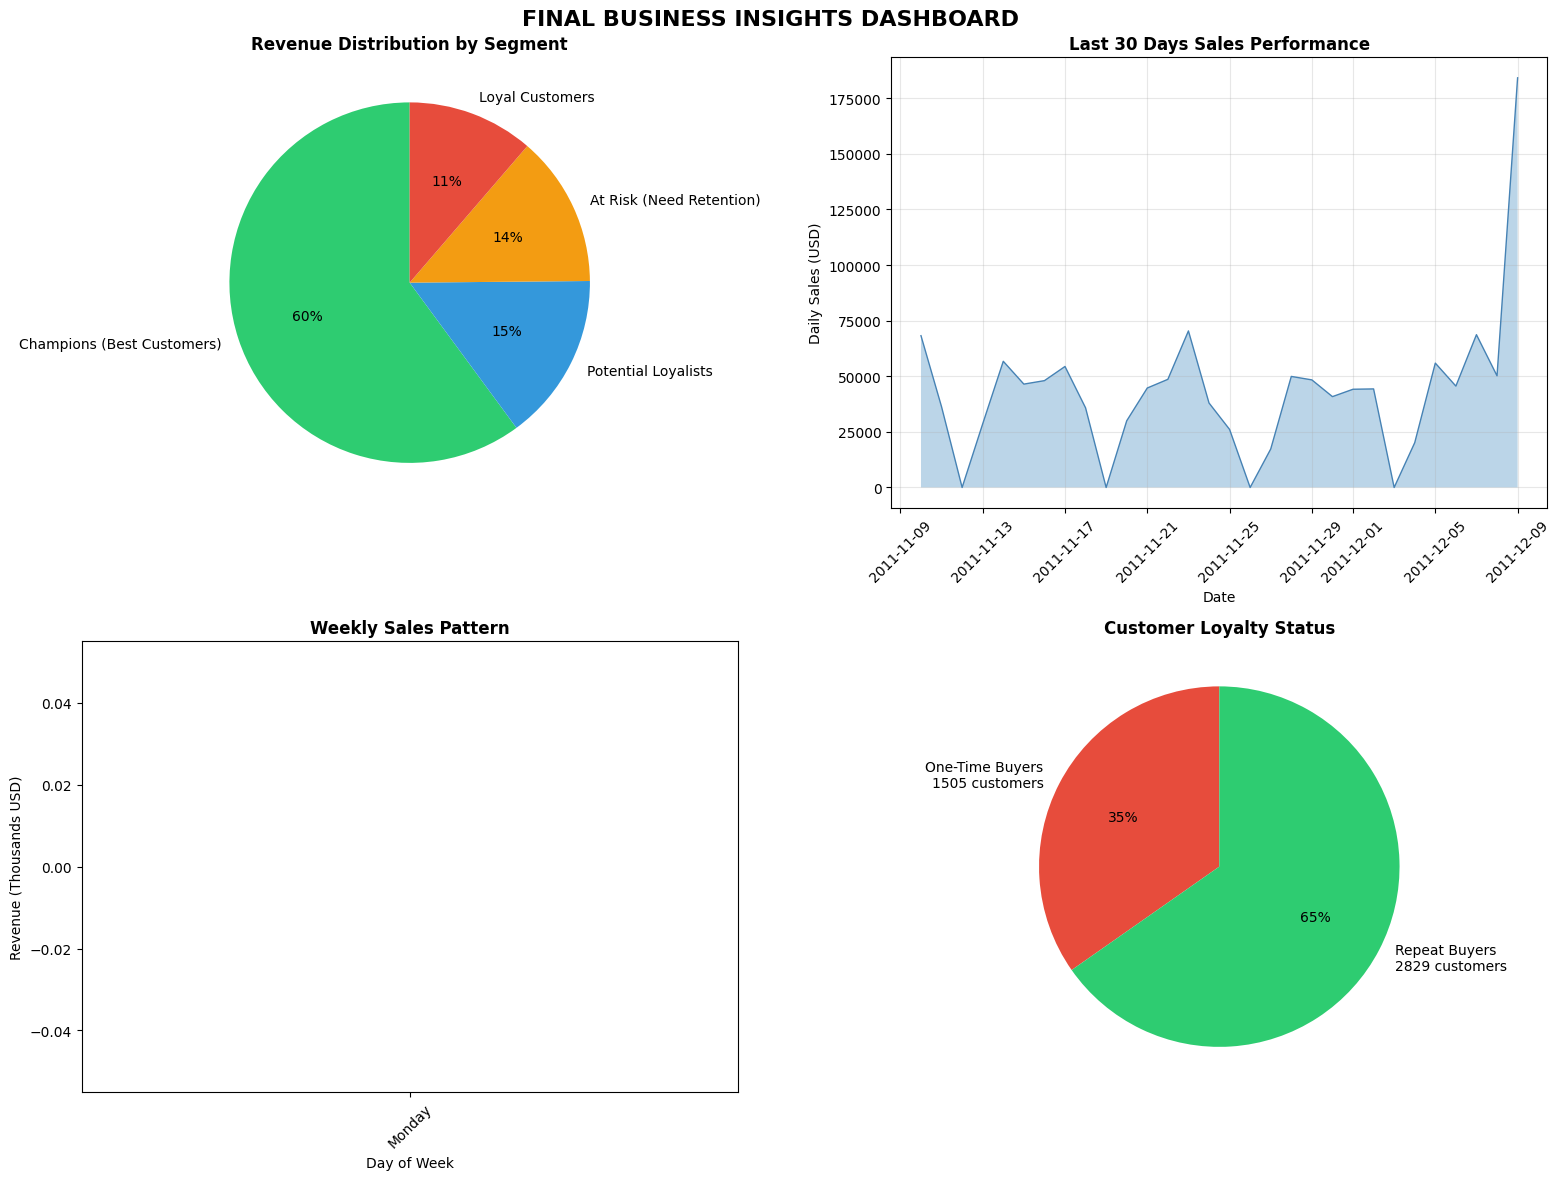

Dashboard saved to ../outputs/figures/final_business_dashboard.png

HOW TO USE THIS DASHBOARD FOR BUSINESS DECISIONS

TOP-LEFT CHART: Revenue Distribution by Segment
--------------------------------------------------
What it shows: Which customer segments generate the most revenue
How to use: Allocate marketing budget to the largest slices
Action: Focus retention efforts on the top 2 segments

TOP-RIGHT CHART: Last 30 Days Sales Performance
--------------------------------------------------
What it shows: Recent daily sales trend
How to use: Identify if sales are increasing or decreasing
Action: Investigate any unexpected drops or celebrate spikes

BOTTOM-LEFT CHART: Weekly Sales Pattern
--------------------------------------------------
What it shows: Which days of week perform best
How to use: Schedule promotions on high-performing days
Action: Send marketing emails on Thursday or Friday

BOTTOM-RIGHT CHART: Customer Loyalty Status
--------------------------------------------------
W

In [9]:
# Create a comprehensive dashboard figure
fig = plt.figure(figsize=(16, 12))

# Chart 1: Revenue by Customer Segment (Pie)
ax1 = plt.subplot(2, 2, 1)
top_segments = segment_analysis.nlargest(4, 'Revenue_Share')
colors_pie = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
ax1.pie(top_segments['Revenue_Share'].values, labels=top_segments.index, autopct='%1.0f%%', 
        colors=colors_pie, startangle=90)
ax1.set_title('Revenue Distribution by Segment', fontweight='bold')

# Chart 2: Daily Sales Pattern (Line)
ax2 = plt.subplot(2, 2, 2)
if len(daily_sales) > 0:
    # Convert to numpy array to avoid dimension issues
    daily_sales_30d = daily_sales.tail(30)
    dates = daily_sales_30d.index
    sales_values = daily_sales_30d.values.flatten()  # Ensure 1-dimensional
    
    ax2.plot(dates, sales_values, color='steelblue', linewidth=1)
    ax2.fill_between(dates, 0, sales_values, alpha=0.3)
    ax2.set_xlabel('Date', fontsize=10)
    ax2.set_ylabel('Daily Sales (USD)', fontsize=10)
    ax2.set_title('Last 30 Days Sales Performance', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)

# Chart 3: Weekday Sales Pattern (Bar)
ax3 = plt.subplot(2, 2, 3)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
if 'DayOfWeek' not in df.columns:
    df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
weekday_sales = df.groupby('DayOfWeek')['TotalPrice'].sum().reindex(weekday_order)
colors_bar = ['#95a5a6', '#95a5a6', '#95a5a6', '#2ecc71', '#2ecc71', '#e74c3c', '#e74c3c']
bars = ax3.bar(weekday_sales.index, weekday_sales.values/1000, color=colors_bar)
ax3.set_xlabel('Day of Week', fontsize=10)
ax3.set_ylabel('Revenue (Thousands USD)', fontsize=10)
ax3.set_title('Weekly Sales Pattern', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, val in zip(bars, weekday_sales.values/1000):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'${val:.0f}K', ha='center', fontsize=8)

# Chart 4: Customer Status (Pie)
ax4 = plt.subplot(2, 2, 4)
customer_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
one_time = (customer_frequency == 1).sum()
repeat = (customer_frequency >= 2).sum()
ax4.pie([one_time, repeat], labels=[f'One-Time Buyers\n{one_time} customers', 
                                     f'Repeat Buyers\n{repeat} customers'], 
        autopct='%1.0f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
ax4.set_title('Customer Loyalty Status', fontweight='bold')

plt.suptitle('FINAL BUSINESS INSIGHTS DASHBOARD', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/final_business_dashboard.png', dpi=150)
plt.show()

print("Dashboard saved to ../outputs/figures/final_business_dashboard.png")

print("\n" + "=" * 70)
print("HOW TO USE THIS DASHBOARD FOR BUSINESS DECISIONS")
print("=" * 70)

print("\nTOP-LEFT CHART: Revenue Distribution by Segment")
print("-" * 50)
print("What it shows: Which customer segments generate the most revenue")
print("How to use: Allocate marketing budget to the largest slices")
print("Action: Focus retention efforts on the top 2 segments")

print("\nTOP-RIGHT CHART: Last 30 Days Sales Performance")
print("-" * 50)
print("What it shows: Recent daily sales trend")
print("How to use: Identify if sales are increasing or decreasing")
print("Action: Investigate any unexpected drops or celebrate spikes")

print("\nBOTTOM-LEFT CHART: Weekly Sales Pattern")
print("-" * 50)
print("What it shows: Which days of week perform best")
print("How to use: Schedule promotions on high-performing days")
print("Action: Send marketing emails on Thursday or Friday")

print("\nBOTTOM-RIGHT CHART: Customer Loyalty Status")
print("-" * 50)
print("What it shows: Percentage of one-time vs repeat buyers")
print("How to use: Track improvement in customer retention")
print("Action: Launch campaigns to convert one-time to repeat buyers")

## Prioritized Business Recommendations

In [13]:
print("=" * 80)
print("PRIORITIZED BUSINESS RECOMMENDATIONS")
print("=" * 80)

print("\n[PRIORITY 1 - IMMEDIATE ACTION] Win-Back At-Risk Customers")
print("-" * 60)
print("Target: Customers who haven't purchased in 90+ days but historically spent >$500")
print("Action: Send personalized re-engagement email with 15-20% discount")
print("Timeline: Within 2 weeks")
print("Expected Impact: 15-20% recovery rate of at-risk revenue")
print("Success Metric: Decrease in high-recency customers by 15%")

print("\n[PRIORITY 2 - SHORT TERM] Optimize Marketing Timing")
print("-" * 60)
print("Target: All customers")
print("Action: Schedule email campaigns for Thursday 12:00 PM")
print("Timeline: Implement within 30 days")
print("Expected Impact: 10-15% increase in email open and conversion rates")
print("Success Metric: Improved revenue on promoted days")

print("\n[PRIORITY 3 - MEDIUM TERM] VIP Program for Top Customers")
print("-" * 60)
print("Target: Top 10% of customers by spending")
print("Action: Create exclusive loyalty program with early access and free shipping")
print("Timeline: Roll out within 60 days")
print("Expected Impact: 20-25% increase in customer lifetime value")
print("Success Metric: Increased purchase frequency from top segment")

print("\n[PRIORITY 4 - LONG TERM] International Expansion")
print("-" * 60)
print("Target: Top 5 international countries by existing revenue")
print("Action: Localized marketing campaigns and shipping optimization")
print("Timeline: 6-month phased rollout")
print("Expected Impact: 30% increase in international revenue")
print("Success Metric: Reduced UK revenue concentration below 80%")

PRIORITIZED BUSINESS RECOMMENDATIONS

[PRIORITY 1 - IMMEDIATE ACTION] Win-Back At-Risk Customers
------------------------------------------------------------
Target: Customers who haven't purchased in 90+ days but historically spent >$500
Action: Send personalized re-engagement email with 15-20% discount
Timeline: Within 2 weeks
Expected Impact: 15-20% recovery rate of at-risk revenue
Success Metric: Decrease in high-recency customers by 15%

[PRIORITY 2 - SHORT TERM] Optimize Marketing Timing
------------------------------------------------------------
Target: All customers
Action: Schedule email campaigns for Thursday 12:00 PM
Timeline: Implement within 30 days
Expected Impact: 10-15% increase in email open and conversion rates
Success Metric: Improved revenue on promoted days

[PRIORITY 3 - MEDIUM TERM] VIP Program for Top Customers
------------------------------------------------------------
Target: Top 10% of customers by spending
Action: Create exclusive loyalty program with earl